In [ ]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
 
dde.backend.backend_name = 'pytorch'

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [4]:
R  = 1.0   
D  = 0.1    
v  = 1.0    
C0 = 1.0    
Ci = 0.0    
L  = 1.0    
t0 = 1.0    

In [5]:
def pde(X, c):
    dc_x = dde.grad.jacobian(c, X, i=0, j=0)
    dc_t = dde.grad.jacobian(c, X, i=0, j=1)
    dc_xx = dde.grad.hessian(c, X, i=0, j=0)
    return R*dc_t - D*dc_xx + v*dc_x

In [6]:
def analytical_sol(x, t):
    eps = 1e-12
    t = np.maximum(t, eps)
    denominator = 2 * np.sqrt(D*R*t)
    
    a = 0.5 * erfc((R*x - v*t)/denominator)
    b = 0.5 * np.exp((v*x)/D)*erfc((R*x + v*t)/denominator)
    c = 0.5 * (2 + v*(2*L - x)/D + v**2*t/(D*R))*np.exp(v*L/D)*erfc((R*(2*L - x) + v*t)/denominator)
    d = np.sqrt(v**2*t/(np.pi*D*R)) * np.exp(v*L/D - R*(2*L - x + v*t/R)**2 / (4*D*t))
    
    return Ci + (C0 - Ci)*(a + b + c - d)
    
    

In [7]:
# Geometry
# ADE :  geom = GeometryXTime (space , time)
geom = dde.geometry.Interval(0, L)
timedomain = dde.geometry.TimeDomain(0, t0)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [8]:
# BOUNDARY CONDITIONS
def boundary_val_left(X):
    return np.full((X.shape[0], 1), C0)

def boundary_left(X, on_boundary):
    return on_boundary and dde.utils.isclose(X[0], 0.0)



def boundary_flux_right(X):
    return np.zeros((X.shape[0], 1))
 
def boundary_right(X, on_boundary):
    return on_boundary and dde.utils.isclose(X[0], L)

In [9]:
bc_left = dde.icbc.DirichletBC(geomtime, boundary_val_left, boundary_left)

bc_right =dde.icbc.NeumannBC(geomtime,boundary_flux_right, boundary_right)

In [10]:
## INITIAL CONDITION
ic = dde.icbc.IC(geomtime, lambda X: np.full((X.shape[0], 1), Ci), lambda X, on_initial: on_initial)

In [11]:
data = dde.data.TimePDE(geomtime, pde, [ic, bc_left, bc_right],
    num_domain   = 3000,   # Training collocation points
    num_boundary = 300,    # boundary points
    num_initial  = 300,    # initial condition points
    num_test     = 1000,   # Testing points
)

In [12]:
layer_size = [2] + [64]*4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)

model = dde.Model(data, net)
## Use adam optimizer
model.compile("adam", lr = 0.001)
losshistory, train_state = model.train(iterations=8000)

## Use L-BFGS optimizer for fine-tuning(improve accuracy)
model.compile("L-BFGS")
losshistory, train_state = model.train(iterations=2000)

Compiling model...
'compile' took 5.020675 s

Training model...

Step      Train loss                                  Test loss                                   Test metric
0         [2.88e-04, 2.92e-05, 1.02e+00, 4.20e-05]    [2.89e-04, 2.92e-05, 1.02e+00, 4.20e-05]    []  
1000      [1.19e-02, 1.11e-02, 1.05e-02, 8.19e-04]    [6.05e-03, 1.11e-02, 1.05e-02, 8.19e-04]    []  
2000      [3.50e-03, 7.37e-03, 7.48e-03, 5.11e-04]    [2.12e-03, 7.37e-03, 7.48e-03, 5.11e-04]    []  
3000      [1.74e-03, 5.77e-03, 5.74e-03, 1.62e-03]    [1.21e-03, 5.77e-03, 5.74e-03, 1.62e-03]    []  
4000      [1.20e-03, 4.55e-03, 4.72e-03, 1.79e-04]    [7.85e-04, 4.55e-03, 4.72e-03, 1.79e-04]    []  
5000      [9.05e-04, 3.69e-03, 4.03e-03, 4.08e-05]    [5.34e-04, 3.69e-03, 4.03e-03, 4.08e-05]    []  
6000      [7.66e-04, 3.08e-03, 3.58e-03, 1.70e-04]    [5.10e-04, 3.08e-03, 3.58e-03, 1.70e-04]    []  
7000      [7.10e-04, 2.86e-03, 3.11e-03, 2.07e-04]    [4.01e-04, 2.86e-03, 3.11e-03, 2.07e-04]    []  
8

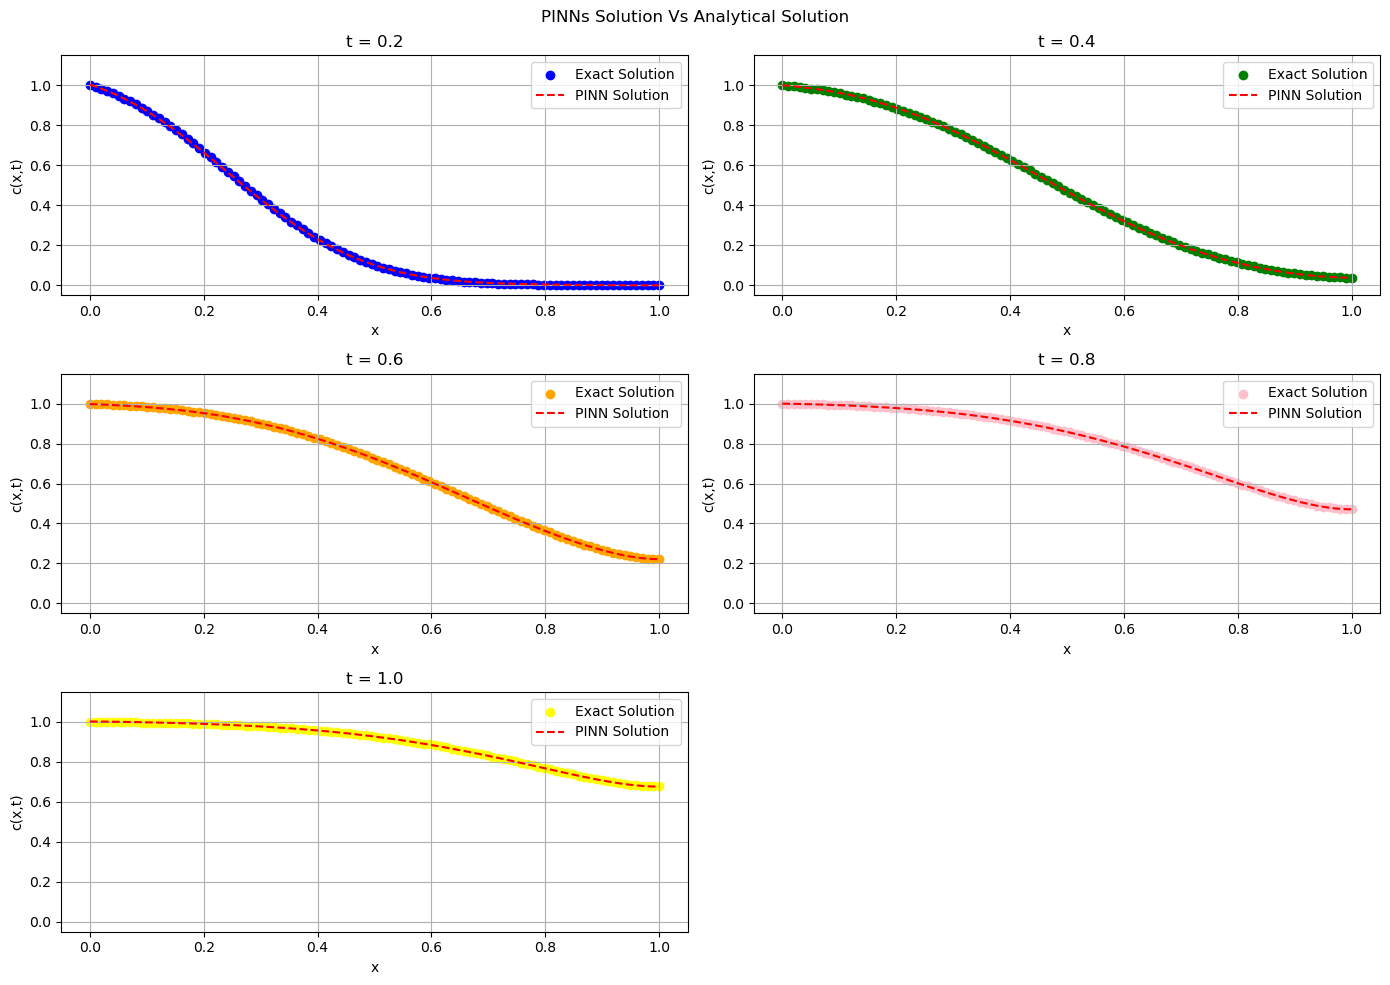

In [13]:
x_val = np.linspace(0, L, 100).reshape(-1, 1)

t_values = [0.2, 0.4, 0.6, 0.8, 1.0]
colors = ['blue', 'green', 'orange', 'pink', 'yellow']

plt.figure(figsize=(14, 10))
plt.suptitle("PINNs Solution Vs Analytical Solution")

for i in range(len(t_values)):  
    t_val = t_values[i]
    
    t_arr = np.full_like(x_val, t_val)
    X_test = np.hstack((x_val, t_arr))
    
    y_pred = model.predict(X_test)
    y_exact = analytical_sol(x_val.flatten(), t_arr.flatten())
    
    plt.subplot(3, 2, i+1)
    
    plt.scatter(x_val, y_exact, color = colors[i], label="Exact Solution")
    plt.plot(x_val, y_pred, 'r--', label="PINN Solution")
    
    plt.title("t = " + str(t_val))
    plt.xlabel("x")
    plt.ylabel("c(x,t)")
    plt.legend()
    plt.grid()
    plt.ylim(-0.05, 1.15)

plt.tight_layout()
plt.show()

In [14]:
## PINNS VERIFICATIONS 1-  Error Metrics (MAE)
for t_val in t_values:
    t_arr   = np.full_like(x_val, t_val)
    X_test  = np.hstack([x_val, t_arr])
    y_pred  = model.predict(X_test).flatten()
    y_exact = analytical_sol(x_val.flatten(), t_arr.flatten())
    mae     = np.mean(np.abs(y_pred - y_exact))
    print(f"  t = {t_val:.1f}  |  MAE = {mae:.6f}")

  t = 0.2  |  MAE = 0.001820
  t = 0.4  |  MAE = 0.001223
  t = 0.6  |  MAE = 0.000934
  t = 0.8  |  MAE = 0.000752
  t = 1.0  |  MAE = 0.000881


  Mean PDE Residual : 0.020608


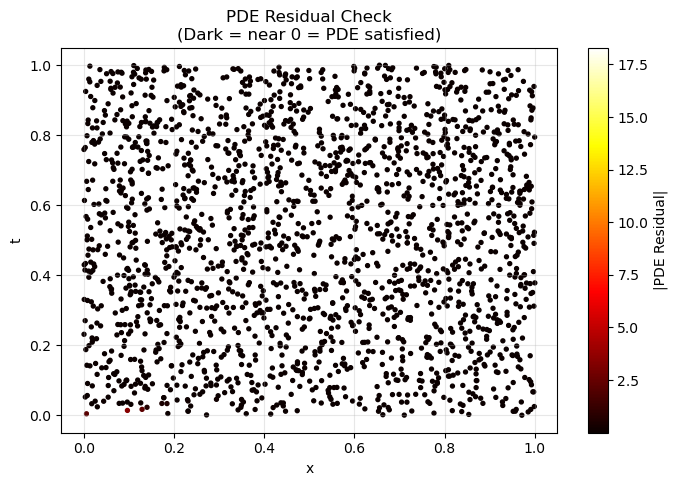

In [15]:
## PINNS VERIFICATION 2 — PDE Residual Check
x_check  = np.random.uniform(0, L,  (2000, 1))
t_check  = np.random.uniform(0, t0, (2000, 1))
X_check  = np.hstack([x_check, t_check])
 
residuals = model.predict(X_check, operator=pde)
mean_res  = np.mean(np.abs(residuals))
 
print(f"  Mean PDE Residual : {mean_res:.6f}")
 
# Plot residual across domain
plt.figure(figsize=(8, 5))
plt.scatter(x_check, t_check, c=np.abs(residuals), cmap='hot', s=8)
plt.colorbar(label='|PDE Residual|')
plt.xlabel("x")
plt.ylabel("t")
plt.title("PDE Residual Check\n(Dark = near 0 = PDE satisfied)")
plt.grid(True, alpha=0.3)
plt.show()

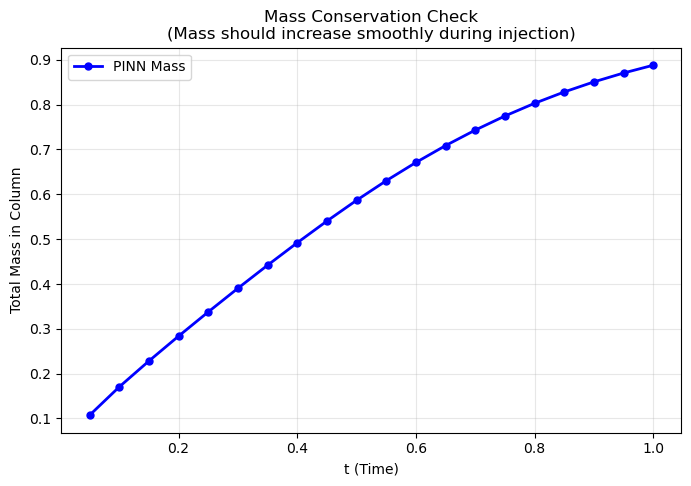

  Mass at t=0.0 : 0.1073  (should be near 0)
  Mass at t=1.0 : 0.8880  (should be increasing)
  Mass increases as expected


In [16]:
# VERIFICATION 3 — Mass Conservation Check  (No analytical solution needed)

x_mass = np.linspace(0, L, 200).reshape(-1, 1)
t_mass = np.linspace(0.05, t0, 20)
mass_pinn = []

for t_val in t_mass:
    t_arr  = np.full_like(x_mass, t_val)
    X_test = np.hstack([x_mass, t_arr])
    c_pred = model.predict(X_test).flatten()

    # Integrate concentration over column length
    mass   = np.trapz(c_pred, x_mass.flatten())
    mass_pinn.append(mass)

# Plot mass vs time
plt.figure(figsize=(8, 5))
plt.plot(t_mass, mass_pinn, 'b-o', linewidth=2, markersize=5, label="PINN Mass")
plt.xlabel("t (Time)")
plt.ylabel("Total Mass in Column")
plt.title("Mass Conservation Check\n(Mass should increase smoothly during injection)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"  Mass at t=0.0 : {mass_pinn[0]:.4f}  (should be near 0)")
print(f"  Mass at t=1.0 : {mass_pinn[-1]:.4f}  (should be increasing)")
if mass_pinn[-1] > mass_pinn[0]:
    print("  Mass increases as expected")
